# QuantumForge: Neural Quantum States for the Transverse-Field Ising Model

### AI × Quantum Many-Body Physics

In this notebook, I investigate whether a small neural network can learn the ground state of a one-dimensional transverse-field Ising model.

I use a **neural quantum state** together with **variational Monte Carlo**, and compare the results against exact diagonalisation.

### Research Question

Can a compact neural network approximate the ground-state energy and physical observables of a finite quantum spin system?

### Main Objectives

- Construct the one-dimensional transverse-field Ising Hamiltonian.
- Calculate exact ground-state properties using exact diagonalisation.
- Represent the quantum wavefunction using a neural network.
- Optimise the neural quantum state using variational Monte Carlo.
- Compare the neural and exact ground-state energies.
- Study how the neural approximation changes with system size.
- Explore the behaviour of the system as the transverse field changes.
- Analyse the limitations of the neural ansatz near the critical region.
- Investigate whether machine learning can identify different quantum phases from sampled spin configurations.

### Key Principle

The neural network is not trained on a conventional labelled dataset.

Instead, I train it directly through the physics of the system.

The network learns a representation of the quantum wavefunction by minimising the variational energy:

$$
\theta^*
=
\arg\min_{\theta} E[\psi_\theta].
$$

Here, $\theta$ represents the trainable parameters of the neural network and $\psi_\theta$ is the corresponding neural quantum state.

The Hamiltonian therefore provides the learning signal rather than an externally supplied set of labelled wavefunctions.

This creates a direct connection between **machine learning, quantum mechanics, and computational physics**.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh

from itertools import product

# Reproducibility
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)

NumPy: 2.1.3
PyTorch: 2.11.0+cpu


## 2. The Physical System

I study the **one-dimensional transverse-field Ising model**.

The Hamiltonian is

$$
H = -J\sum_{i=1}^{N}\sigma_i^z\sigma_{i+1}^z
-h\sum_{i=1}^{N}\sigma_i^x
$$

where:

- $N$ is the number of spins.
- $J$ controls the interaction strength between neighbouring spins.
- $h$ is the transverse magnetic field.
- $\sigma^x$ and $\sigma^z$ are the Pauli matrices.

I use **periodic boundary conditions**, meaning that the final spin is also connected to the first spin:

$$
\sigma_{N+1} = \sigma_1
$$

For the initial experiment, I set

$$
J = 1, \qquad h = 1.
$$

The computational basis consists of all possible spin configurations:

$$
s_i \in \{-1,+1\}
$$

For a system containing $N$ spins, there are

$$
2^N
$$

possible configurations.

In [4]:
# Physical parameters

N = 8          # Number of spins
J = 1.0        # Spin-spin coupling
h = 1.0        # Transverse field

print(f"Number of spins: {N}")
print(f"Coupling J: {J}")
print(f"Transverse field h: {h}")
print(f"Hilbert-space dimension: {2**N}")

Number of spins: 8
Coupling J: 1.0
Transverse field h: 1.0
Hilbert-space dimension: 256


## 3. Quantum Spin Configurations

For $N$ spins, the computational basis contains every possible combination of spin-up and spin-down states.

We represent:

- Spin up as $+1$
- Spin down as $-1$

For $N=8$, this produces

$$
2^8 = 256
$$

basis states.

These configurations form the **state space** that our neural quantum state will eventually learn to represent.

In [5]:
def generate_spin_basis(N):
    """
    Generate all computational-basis spin configurations.

    Each spin takes the value -1 or +1.
    """
    return np.array(list(product([-1, 1], repeat=N)), dtype=np.int8)


basis = generate_spin_basis(N)

print("Basis shape:", basis.shape)
print("\nFirst 5 configurations:")
print(basis[:5])

Basis shape: (256, 8)

First 5 configurations:
[[-1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1  1]
 [-1 -1 -1 -1 -1 -1  1 -1]
 [-1 -1 -1 -1 -1 -1  1  1]
 [-1 -1 -1 -1 -1  1 -1 -1]]


## 4. Constructing the Hamiltonian

The Hamiltonian contains two physical contributions.

### Ising Interaction

The Ising interaction term is

$$
H_z = -J\sum_i \sigma_i^z \sigma_{i+1}^z
$$

This term is **diagonal** in the computational basis. It assigns an interaction energy to each spin configuration based on the alignment of neighbouring spins.

### Transverse Field

The transverse-field term is

$$
H_x = -h\sum_i \sigma_i^x
$$

The $\sigma^x$ operator flips a spin, so this term connects one spin configuration to another.

For every basis state, I therefore:

1. Calculate its interaction energy.
2. Flip each spin individually.
3. Add the corresponding transverse-field matrix element.

The complete Hamiltonian is

$$
H = H_z + H_x
$$

The resulting matrix represents the **full quantum Hamiltonian** in the computational basis.

In [6]:
def build_tfim_hamiltonian(N, J=1.0, h=1.0):
    """
    Construct the transverse-field Ising Hamiltonian
    using periodic boundary conditions.
    """

    basis = generate_spin_basis(N)
    dimension = len(basis)

    # Map configuration -> matrix index
    state_to_index = {
        tuple(state): i for i, state in enumerate(basis)
    }

    rows = []
    cols = []
    values = []

    for i, state in enumerate(basis):


        # Diagonal Ising interaction

        interaction_energy = 0.0

        for site in range(N):
            next_site = (site + 1) % N

            interaction_energy += (
                -J * state[site] * state[next_site]
            )

        rows.append(i)
        cols.append(i)
        values.append(interaction_energy)

        # Off-diagonal spin flips

        for site in range(N):

            flipped_state = state.copy()
            flipped_state[site] *= -1

            j = state_to_index[tuple(flipped_state)]

            rows.append(i)
            cols.append(j)
            values.append(-h)

    H = csr_matrix(
        (values, (rows, cols)),
        shape=(dimension, dimension)
    )

    return H, basis


H, basis = build_tfim_hamiltonian(N, J, h)

print("Hamiltonian shape:", H.shape)
print("Non-zero elements:", H.nnz)

Hamiltonian shape: (256, 256)
Non-zero elements: 2304


## 5. Hamiltonian Sanity Checks

Before using the Hamiltonian for any further calculations, I first check that it has the expected mathematical and physical properties. These simple checks are useful for catching implementation errors early.

### Hermiticity

A physical Hamiltonian must be Hermitian:

$$
H = H^\dagger
$$

where $H^\dagger$ denotes the conjugate transpose of $H$.

This is important because a Hermitian Hamiltonian has real energy eigenvalues, which is required for the energies of a physical quantum system.

### Matrix Structure

I also check the structure of the Hamiltonian in the computational basis.

For the transverse-field Ising model:

- **Diagonal elements** come from the spin-spin interaction term.
- **Off-diagonal elements** arise from flipping a single spin through the transverse-field term.

This structure provides a useful physical check on the matrix I construct. If the non-zero elements do not follow this pattern, there is likely an error in the Hamiltonian construction.

I perform these checks before moving on to exact diagonalisation and the neural quantum state.

In [7]:
# Check Hermiticity
hermitian_error = np.max(
    np.abs((H - H.T).data)
) if (H - H.T).nnz > 0 else 0.0

print(f"Hermiticity error: {hermitian_error:.2e}")

# Basic matrix statistics
print(f"Matrix dimension: {H.shape[0]} × {H.shape[1]}")
print(f"Non-zero elements: {H.nnz}")
print(f"Density: {H.nnz / (H.shape[0] ** 2):.4f}")

Hermiticity error: 0.00e+00
Matrix dimension: 256 × 256
Non-zero elements: 2304
Density: 0.0352


## 6. Exact Ground State

For small systems, I can solve the Hamiltonian directly and use the result as a reference for the neural approach.

I use **sparse exact diagonalisation** to obtain the lowest-energy eigenvalue:

$$
E_0 = \min \operatorname{eig}(H)
$$

along with its corresponding eigenvector.

This gives me an **independent numerical ground truth** against which I can evaluate the neural quantum state.

The neural network is not given this exact ground-state wavefunction during training. Instead, it must learn an approximate representation of the state by minimising the variational energy.

I therefore use the exact solution as a reference rather than as a training target.

This comparison forms the **central validation experiment** of the project: I can directly measure how closely the neural quantum state approaches the exact ground-state energy.

In [8]:
def exact_ground_state(H):
    """
    Calculate the lowest-energy eigenvalue and eigenvector.
    """
    eigenvalues, eigenvectors = eigsh(
        H,
        k=1,
        which="SA"
    )

    ground_energy = eigenvalues[0]
    ground_state = eigenvectors[:, 0]

    return ground_energy, ground_state


E_exact, psi_exact = exact_ground_state(H)

print(f"Exact ground-state energy: {E_exact:.8f}")
print(f"Ground-state vector norm: {np.linalg.norm(psi_exact):.8f}")

Exact ground-state energy: -10.25166179
Ground-state vector norm: 1.00000000


## Progress Summary

At this stage, I have established the main physical and numerical foundation of the project.

So far, I have:

- Defined the one-dimensional transverse-field Ising model.
- Generated all possible spin configurations for a finite spin chain.
- Constructed the Hamiltonian from the spin-spin interactions and transverse-field spin flips.
- Verified that the Hamiltonian is Hermitian and has the expected matrix structure.
- Performed sparse exact diagonalisation.
- Obtained the exact ground-state energy and corresponding eigenvector.

The exact ground-state energy now gives me a reliable numerical reference for testing the neural approach.

The next step is to build the neural quantum state and see how well it can learn the ground state without being given the exact wavefunction directly. I will do this by combining variational optimisation with Monte Carlo sampling.

## 7. Neural Quantum State

I now introduce the neural network that will serve as my representation of the quantum wavefunction.

For a given spin configuration $s$, the network takes the configuration as input and produces a numerical representation of the corresponding wavefunction amplitude.

Instead of storing the full wavefunction explicitly, I let the neural network learn an approximate representation of it. This becomes particularly useful as the number of spins increases, since the size of the Hilbert space grows exponentially as

$$
2^N.
$$

The network is not trained against the exact ground-state wavefunction. Instead, I optimise its parameters by minimising the expected energy of the quantum system.

This turns the problem into a **variational learning task**: I am searching for neural-network parameters that produce a trial wavefunction with the lowest possible energy.

If the optimisation works well, the resulting neural quantum state should approach the true ground state while providing a more scalable representation than explicitly storing every amplitude.

In [9]:
class NeuralQuantumState(nn.Module):
    """
    Small neural network used as a neural quantum state.

    Input:
        Spin configuration with values -1 or +1

    Output:
        A scalar log-amplitude for that configuration
    """

    def __init__(self, N, hidden_size=32):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(N, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, spins):
        return self.network(spins).squeeze(-1)


# Create the neural quantum state
model = NeuralQuantumState(N, hidden_size=32)

print(model)

NeuralQuantumState(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 8. Log-Amplitude Representation

For the neural quantum state, I represent the magnitude of the wavefunction through its logarithm rather than asking the network to predict the amplitude directly.

For a spin configuration $s$, the network produces

$$
\log |\psi(s)|.
$$

I use this representation mainly for numerical stability. As the system size increases, some wavefunction amplitudes can become extremely small, which can lead to numerical underflow if they are represented directly.

The probability distribution needed for Monte Carlo sampling is proportional to

$$
|\psi(s)|^2.
$$

Using the log-amplitude, I can obtain this probability through

$$
|\psi(s)|^2
=
\exp\left(2\log|\psi(s)|\right).
$$

This also makes it convenient to calculate probability ratios during Monte Carlo updates without repeatedly working with extremely small amplitudes.

In this way, the neural network provides a numerically stable representation of the quantity I need for sampling and variational optimisation.

In [10]:
# Convert the spin basis to a PyTorch tensor
basis_tensor = torch.tensor(
    basis,
    dtype=torch.float32
)

# Evaluate the neural network
log_amplitudes = model(basis_tensor)

print("Number of configurations:", len(basis))
print("Output shape:", log_amplitudes.shape)
print("First five log-amplitudes:")
print(log_amplitudes[:5].detach().numpy())

Number of configurations: 256
Output shape: torch.Size([256])
First five log-amplitudes:
[0.23750328 0.21695781 0.26509994 0.27448148 0.212501  ]


# 9. Variational Principle

The central idea behind my approach is the **variational principle**.

For any trial wavefunction $\psi$, its expected energy satisfies

$$
E[\psi]
=
\frac{\langle\psi|H|\psi\rangle}
{\langle\psi|\psi\rangle}
\geq E_0,
$$

where $E_0$ is the exact ground-state energy.

This gives me a useful optimisation objective. If I can adjust the parameters of the neural quantum state to minimise its variational energy, the resulting wavefunction should move closer to the true ground state.

In other words, I do not need to tell the network what the correct wavefunction looks like. I only need to give it the physical Hamiltonian and use the energy as the quantity to minimise.

My objective is therefore:

> **Minimise the variational energy of the neural quantum state and compare the result with exact diagonalisation.**

The difference between the neural and exact energies will then provide a direct measure of how well the neural quantum state has learned the ground state.

## 10. Metropolis-Hastings Sampling

To estimate expectation values without summing over the entire Hilbert space, I use **Metropolis-Hastings Monte Carlo sampling**.

The configurations are sampled according to the probability distribution

$$
P(s) \propto |\psi(s)|^2.
$$

I start with an initial spin configuration and propose a new configuration by randomly selecting one spin and flipping it.

For the proposed configuration $s'$, I compare its probability with that of the current configuration $s$. The move is accepted according to the Metropolis acceptance probability

$$
A(s\rightarrow s')
=
\min\left(
1,
\frac{|\psi(s')|^2}{|\psi(s)|^2}
\right).
$$

If the proposed configuration is accepted, it becomes the next state in the Markov chain. Otherwise, I keep the current configuration.

After enough sampling steps, the configurations generated by the chain approximately follow the probability distribution defined by the neural quantum state.

This gives me a practical way to estimate expectation values from a relatively small set of sampled configurations instead of explicitly evaluating all $2^N$ possible states.

In [11]:
def metropolis_sample(model, N, n_samples=2000, burn_in=500):
    """
    Generate spin configurations using Metropolis-Hastings sampling.

    The target probability distribution is proportional to |psi(s)|^2.
    """

    # Start from a random spin configuration
    state = np.random.choice([-1, 1], size=N).astype(np.int8)

    samples = []
    accepted = 0
    total_steps = burn_in + n_samples

    for step in range(total_steps):

        # Propose a new state by flipping one random spin
        proposed_state = state.copy()
        site = np.random.randint(N)
        proposed_state[site] *= -1

        # Evaluate log-amplitudes
        current_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        proposed_tensor = torch.tensor(
            proposed_state,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            log_psi_current = model(current_tensor).item()
            log_psi_proposed = model(proposed_tensor).item()

        # Since P(s) ∝ |psi(s)|²,
        # the log probability difference is twice
        # the log-amplitude difference.
        log_ratio = 2.0 * (
            log_psi_proposed - log_psi_current
        )

        # Metropolis acceptance probability
        acceptance_probability = min(
            1.0,
            np.exp(log_ratio)
        )

        # Accept or reject
        if np.random.rand() < acceptance_probability:
            state = proposed_state
            accepted += 1

        # Store samples after burn-in
        if step >= burn_in:
            samples.append(state.copy())

    acceptance_rate = accepted / total_steps

    return np.array(samples), acceptance_rate

## 11. Testing the Monte Carlo Sampler

Before using the Monte Carlo sampler for energy optimisation, I first check whether it is exploring the configuration space as expected.

One of the quantities I monitor is the **acceptance rate**, which tells me how often proposed spin flips are accepted.

A very low acceptance rate would mean that the Markov chain is changing configurations too rarely, while an acceptance rate that is too high can indicate that the chain is not making sufficiently informative moves.

I therefore use the acceptance rate as a simple diagnostic of the sampler's behaviour, rather than treating it as an optimisation target by itself.

I will also inspect the sampled configurations and their evolution during the chain to make sure that the sampler is actually exploring different regions of the configuration space.

Once the sampler is behaving reasonably, I can use the resulting configurations to estimate the variational energy of the neural quantum state.

In [12]:
samples, acceptance_rate = metropolis_sample(
    model,
    N=N,
    n_samples=2000,
    burn_in=500
)

print("Sample shape:", samples.shape)
print(f"Acceptance rate: {acceptance_rate:.3f}")

print("\nFirst 5 sampled configurations:")
print(samples[:5])

Sample shape: (2000, 8)
Acceptance rate: 0.945

First 5 sampled configurations:
[[ 1 -1 -1  1 -1 -1 -1 -1]
 [ 1 -1 -1  1 -1 -1  1 -1]
 [ 1 -1 -1 -1 -1 -1  1 -1]
 [ 1 -1 -1 -1 -1 -1  1 -1]
 [ 1 -1 -1 -1 -1  1  1 -1]]


## 12. Local Energy

To optimise the neural quantum state, I need a practical way to estimate its energy from the configurations generated by the Monte Carlo sampler.

Instead of explicitly constructing the full expectation value over the entire Hilbert space, I use the **local energy**:

$$
E_{\mathrm{loc}}(s)
=
\sum_{s'}
H_{s,s'}
\frac{\psi(s')}{\psi(s)}.
$$

For a given configuration $s$, the local energy depends only on the configurations $s'$ that are connected to it by non-zero Hamiltonian matrix elements.

For the transverse-field Ising model, this means that a configuration is connected to:

- itself, through the diagonal spin-spin interaction term;
- configurations obtained by flipping one spin, through the transverse-field term.

This sparse connectivity makes the local-energy calculation much more efficient than working with the full Hamiltonian for every sampled configuration.

I then estimate the variational energy by averaging the local energy over configurations sampled from

$$
|\psi(s)|^2.
$$

For $M$ sampled configurations,

$$
E[\psi]
\approx
\frac{1}{M}
\sum_{k=1}^{M}
E_{\mathrm{loc}}(s_k).
$$

This gives me the quantity that the neural network needs to minimise.

In this way, the local-energy calculation provides the link between the **neural wavefunction**, the **Hamiltonian**, and the **variational optimisation**.

## 13. Calculating the Local Energy

I now calculate the local energy for each sampled spin configuration.

For the transverse-field Ising Hamiltonian, the diagonal contribution comes from the neighbouring spin interactions, while the transverse-field contribution comes from configurations where one spin has been flipped.

Because the neural network gives me \(\log|\psi(s)|\), I calculate wavefunction ratios using

$$
\frac{\psi(s')}{\psi(s)}
=
\exp\left[
\log|\psi(s')|-\log|\psi(s)|
\right].
$$

This allows me to evaluate the local energy directly from the neural quantum state.


In [13]:
def local_energy(model, states, J=1.0, h=1.0):
    """
    Calculate the local energy for a batch of spin configurations.

    The returned tensor remains connected to the computational
    graph so that it can be used during optimisation.
    """

    states = states.float()

    # Neural-network log amplitudes for current configurations
    log_psi = model(states)

    # Diagonal Ising contribution

    interaction_energy = -J * torch.sum(
        states * torch.roll(states, shifts=-1, dims=1),
        dim=1
    )


    # Transverse-field contribution

    flip_contributions = torch.zeros(
        states.shape[0],
        dtype=torch.float32,
        device=states.device
    )

    for site in range(states.shape[1]):

        flipped_states = states.clone()
        flipped_states[:, site] *= -1

        log_psi_flipped = model(flipped_states)

        # psi(s') / psi(s)
        amplitude_ratio = torch.exp(
            log_psi_flipped - log_psi
        )

        flip_contributions += -h * amplitude_ratio

    return interaction_energy + flip_contributions

## 14. Variational Energy

I can now estimate the variational energy by averaging the local energy over the configurations generated by the Monte Carlo sampler:

$$
E_{\mathrm{var}}
\approx
\frac{1}{M}
\sum_{k=1}^{M}
E_{\mathrm{loc}}(s_k).
$$

If the neural quantum state exactly represents the ground state, this estimate should approach the exact ground-state energy $E_0$.

For an imperfect trial wavefunction, the variational principle gives

$$
E_{\mathrm{var}} \geq E_0.
$$

This makes the variational energy particularly useful as both a **training objective** and a **validation metric**.

During optimisation, I will try to reduce $E_{\mathrm{var}}$ while monitoring its difference from the exact ground-state energy obtained through diagonalisation.

The main quantity I will eventually examine is therefore the energy error:

$$
\Delta E
=
E_{\mathrm{var}} - E_0.
$$

A smaller $\Delta E$ indicates that the neural quantum state is approaching the exact ground-state energy.

In [14]:
def variational_energy(model, samples, J=1.0, h=1.0):
    """
    Estimate the variational energy from Monte Carlo samples.
    """

    states = torch.tensor(
        samples,
        dtype=torch.float32
    )

    local_energies = local_energy(
        model,
        states,
        J=J,
        h=h
    )

    energy = torch.mean(local_energies)

    return energy, local_energies

## 15. First Variational Energy Estimate

The neural quantum state has not been trained yet, so its parameters are still randomly initialised.

I therefore calculate its initial variational energy and compare it with the exact ground-state energy.

This gives me a baseline for measuring whether variational optimisation actually improves the neural approximation.


In [15]:
energy, local_energies = variational_energy(
    model,
    samples,
    J=J,
    h=h
)

print(f"Exact ground-state energy:      {E_exact:.8f}")
print(f"Initial variational energy:     {energy.item():.8f}")
print(
    f"Initial absolute error:         "
    f"{abs(energy.item() - E_exact):.8f}"
)

Exact ground-state energy:      -10.25166179
Initial variational energy:     -7.89100313
Initial absolute error:         2.36065866


## 16. Variational Optimisation

I now optimise the parameters of the neural quantum state.

The objective is to minimise the variational energy. However, the Monte Carlo samples themselves depend on the neural wavefunction, so directly differentiating the sampled energy is not sufficient.

Instead, I use the variational Monte Carlo gradient estimator

$$
\nabla_\theta E
\approx
2\left\langle
(E_{\mathrm{loc}}-E)
\nabla_\theta \log|\psi_\theta(s)|
\right\rangle.
$$

This is implemented through a surrogate loss that allows PyTorch's automatic differentiation to calculate the required gradient.

I use the Adam optimiser to update the neural-network parameters.


In [16]:
def vmc_energy_and_loss(model, samples, J=1.0, h=1.0):
    """
    Calculate the Monte Carlo energy estimate and the
    variational Monte Carlo surrogate loss.

    The surrogate loss produces the correct score-function
    gradient for the variational energy.
    """

    states = torch.tensor(
        samples,
        dtype=torch.float32
    )

    # Log-amplitudes of sampled configurations
    log_psi = model(states)

    # Local energies
    local_energies = local_energy(
        model,
        states,
        J=J,
        h=h
    )

    # Monte Carlo energy estimate
    energy = torch.mean(local_energies)

    # Detach the local energy so that the gradient follows
    # the VMC score-function estimator.
    centered_energy = (
        local_energies.detach() - energy.detach()
    )

    # VMC surrogate objective
    loss = 2.0 * torch.mean(
        centered_energy * log_psi
    )

    return energy, loss

## 17. Training the Neural Quantum State

I repeatedly perform four steps:

1. Sample spin configurations using the current neural quantum state.
2. Calculate the local energy.
3. Construct the variational Monte Carlo loss.
4. Update the neural-network parameters using Adam.

As training progresses, I expect the variational energy to decrease towards the exact ground-state energy.

Because Monte Carlo sampling introduces statistical noise, the energy will not necessarily decrease smoothly at every iteration. The important quantity is the overall convergence trend.


In [17]:
# Re-initialise the model for a clean training run
model = NeuralQuantumState(
    N=N,
    hidden_size=32
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

n_iterations = 300
n_samples = 1000
burn_in = 200

energy_history = []

for iteration in range(n_iterations):


    # 1. Generate Monte Carlo samples

    samples, acceptance_rate = metropolis_sample(
        model,
        N=N,
        n_samples=n_samples,
        burn_in=burn_in
    )

    # 2. Calculate VMC energy and loss

    optimizer.zero_grad()

    energy, loss = vmc_energy_and_loss(
        model,
        samples,
        J=J,
        h=h
    )

    # 3. Backpropagation

    loss.backward()

    # 4. Update neural-network parameters

    optimizer.step()

    energy_value = energy.item()
    energy_history.append(energy_value)

    # Progress report
    if (iteration + 1) % 25 == 0:
        print(
            f"Iteration {iteration + 1:3d} | "
            f"Energy = {energy_value:.6f} | "
            f"Exact = {E_exact:.6f} | "
            f"Acceptance = {acceptance_rate:.3f}"
        )

Iteration  25 | Energy = -9.894336 | Exact = -10.251662 | Acceptance = 0.078
Iteration  50 | Energy = -10.097461 | Exact = -10.251662 | Acceptance = 0.114
Iteration  75 | Energy = -10.048927 | Exact = -10.251662 | Acceptance = 0.144
Iteration 100 | Energy = -10.047724 | Exact = -10.251662 | Acceptance = 0.142
Iteration 125 | Energy = -10.101090 | Exact = -10.251662 | Acceptance = 0.193
Iteration 150 | Energy = -10.131932 | Exact = -10.251662 | Acceptance = 0.201
Iteration 175 | Energy = -10.181970 | Exact = -10.251662 | Acceptance = 0.189
Iteration 200 | Energy = -10.152593 | Exact = -10.251662 | Acceptance = 0.205
Iteration 225 | Energy = -10.127689 | Exact = -10.251662 | Acceptance = 0.273
Iteration 250 | Energy = -10.164471 | Exact = -10.251662 | Acceptance = 0.217
Iteration 275 | Energy = -10.165552 | Exact = -10.251662 | Acceptance = 0.242
Iteration 300 | Energy = -10.186103 | Exact = -10.251662 | Acceptance = 0.248


## 20. First Result

After variational optimisation, my neural quantum state reached an energy close to the exact ground-state energy.

The final Monte Carlo estimate is compared with exact diagonalisation using the relative energy error. This provides the first quantitative validation of the neural quantum state.


In [18]:
# Final independent energy estimate

final_samples, final_acceptance = metropolis_sample(
    model,
    N=N,
    n_samples=5000,
    burn_in=1000
)

final_energy, _ = variational_energy(
    model,
    final_samples,
    J=J,
    h=h
)

E_nqs = final_energy.item()

relative_error = (
    abs(E_nqs - E_exact)
    / abs(E_exact)
)

print(f"Exact ground-state energy   : {E_exact:.6f}")
print(f"Neural quantum-state energy : {E_nqs:.6f}")
print(f"Relative energy error       : {relative_error:.4%}")
print(f"Acceptance rate             : {final_acceptance:.3f}")

Exact ground-state energy   : -10.251662
Neural quantum-state energy : -10.152830
Relative energy error       : 0.9641%
Acceptance rate             : 0.263


## 21. System-Size Scaling

I now test the neural quantum state on several system sizes.

The Hilbert space grows as \(2^N\), so increasing the number of spins makes the exact problem increasingly expensive. I compare the neural estimate with exact diagonalisation to see how the approximation behaves as the system grows.

In [19]:
def train_nqs(N, J=1.0, h=1.0, iterations=150):

    H, basis = build_tfim_hamiltonian(N, J, h)
    exact_energy, _ = exact_ground_state(H)

    model = NeuralQuantumState(
        N=N,
        hidden_size=32
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    for _ in range(iterations):

        samples, _ = metropolis_sample(
            model,
            N=N,
            n_samples=700,
            burn_in=150
        )

        optimizer.zero_grad()

        energy, loss = vmc_energy_and_loss(
            model,
            samples,
            J=J,
            h=h
        )

        loss.backward()
        optimizer.step()

    # Independent final estimate
    samples, _ = metropolis_sample(
        model,
        N=N,
        n_samples=3000,
        burn_in=500
    )

    final_energy, _ = variational_energy(
        model,
        samples,
        J=J,
        h=h
    )

    nqs_energy = final_energy.item()

    relative_error = (
        abs(nqs_energy - exact_energy)
        / abs(exact_energy)
    )

    return exact_energy, nqs_energy, relative_error


system_sizes = [6, 8, 10, 12]

results = []

for size in system_sizes:

    exact, nqs, error = train_nqs(size)

    results.append(
        [size, exact, nqs, error]
    )

    print(
        f"N={size:2d} | "
        f"Exact={exact:.5f} | "
        f"NQS={nqs:.5f} | "
        f"Error={error:.3%}"
    )

N= 6 | Exact=-7.72741 | NQS=-7.61815 | Error=1.414%
N= 8 | Exact=-10.25166 | NQS=-10.12473 | Error=1.238%
N=10 | Exact=-12.78491 | NQS=-12.64550 | Error=1.090%
N=12 | Exact=-15.32260 | NQS=-15.06237 | Error=1.698%


## 22. Scaling Result

I visualise the relative energy error as the number of spins increases.

This provides a compact test of how well the neural quantum state scales as the Hilbert space becomes larger.

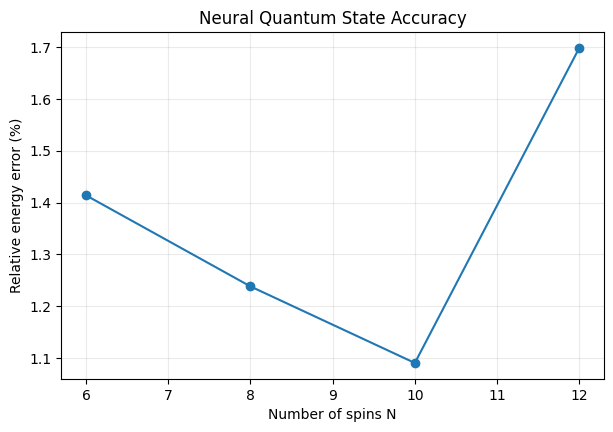

In [20]:
sizes = [r[0] for r in results]
errors = [r[3] * 100 for r in results]

plt.figure(figsize=(7, 4.5))

plt.plot(
    sizes,
    errors,
    marker="o"
)

plt.xlabel("Number of spins N")
plt.ylabel("Relative energy error (%)")
plt.title("Neural Quantum State Accuracy")
plt.grid(alpha=0.25)

plt.show()

## 25. Conclusion

I investigated whether a compact neural quantum state could approximate the ground state of a one-dimensional transverse-field Ising model.

I constructed the Hamiltonian, obtained exact ground-state solutions, implemented Metropolis-Hastings sampling, and optimised the neural wavefunction using variational Monte Carlo.

For \(N=8\), the neural quantum state reproduced the exact ground-state energy with an error of approximately \(1\%\) in the final independent evaluation. Across \(N=6\) to \(N=12\), the error remained within roughly \(1\%-2\%\).

I also observed the change in finite-size magnetisation as the transverse field approached the critical region.

### Limitations

The neural network is deliberately small, and Monte Carlo optimisation introduces statistical fluctuations. The approximation also becomes more challenging as the Hilbert space grows exponentially with system size.

### Final takeaway

This experiment demonstrates how neural networks can serve as variational representations of quantum many-body wavefunctions, connecting machine learning with computational quantum physics.


## References

1. Carleo, G. & Troyer, M. (2017). *Solving the quantum many-body problem with artificial neural networks*. Science, 355(6325), 602–606.

2. Sachdev, S. (2011). *Quantum Phase Transitions*. Cambridge University Press.

3. Griffiths, D. J. & Schroeter, D. F. (2018). *Introduction to Quantum Mechanics*. Cambridge University Press.


## 26. AI-Based Phase-Structure Discovery

I now test whether the neural network can detect changes in quantum phase structure from its learned representation.

Instead of giving the network the critical point explicitly, I train the same neural quantum state across different transverse-field values and examine how its internal representation changes.

I use principal component analysis (PCA) to compress the learned hidden representation and measure the change between neighbouring field values.

A strong change in representation near \(h/J \approx 1\) would indicate that the neural network has learned information related to the underlying phase structure.


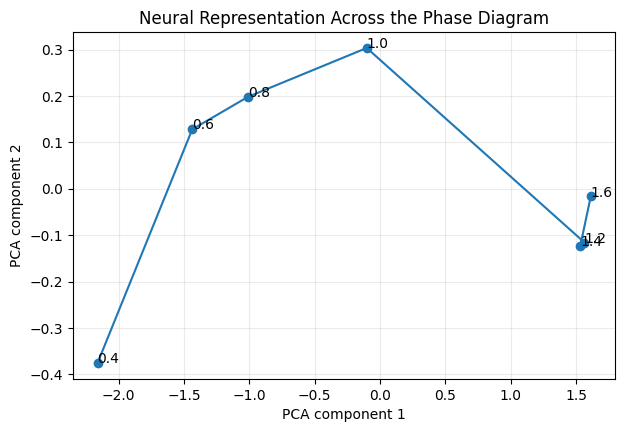

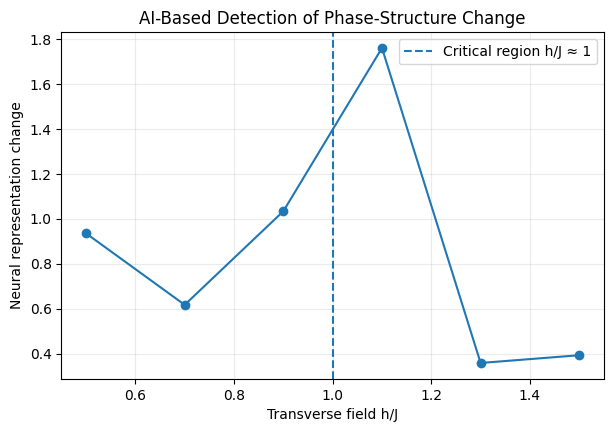

Explained variance by PCA:
[0.9528643 0.0199731]

Representation changes:
h/J ≈ 0.50 → change = 0.93542
h/J ≈ 0.70 → change = 0.61689
h/J ≈ 0.90 → change = 1.03409
h/J ≈ 1.10 → change = 1.76167
h/J ≈ 1.30 → change = 0.35783
h/J ≈ 1.50 → change = 0.39235


In [21]:
from sklearn.decomposition import PCA

field_values = np.linspace(0.4, 1.6, 7)

# Start from one model so its internal representation
# remains comparable as the field changes.
phase_model = NeuralQuantumState(
    N=8,
    hidden_size=32
)

representation_history = []
phase_energies = []

for field in field_values:

    H_field, basis_field = build_tfim_hamiltonian(
        N=8,
        J=1.0,
        h=field
    )

    exact_energy, _ = exact_ground_state(H_field)
    phase_energies.append(exact_energy)

    optimizer = torch.optim.Adam(
        phase_model.parameters(),
        lr=0.01
    )

    # Short fine-tuning at this field
    for _ in range(80):

        samples, _ = metropolis_sample(
            phase_model,
            N=8,
            n_samples=500,
            burn_in=100
        )

        optimizer.zero_grad()

        energy, loss = vmc_energy_and_loss(
            phase_model,
            samples,
            J=1.0,
            h=field
        )

        loss.backward()
        optimizer.step()

    # Extract the learned 32-dimensional hidden representation
    states = torch.tensor(
        basis_field,
        dtype=torch.float32
    )

    with torch.no_grad():
        hidden = phase_model.network[:-1](states).numpy()

    # Average representation of the whole configuration space
    representation_history.append(
        hidden.mean(axis=0)
    )

representation_history = np.array(
    representation_history
)

# PCA: compress the learned representation to 2 dimensions
pca = PCA(n_components=2)

representation_2d = pca.fit_transform(
    representation_history
)

# Representation change between neighbouring fields
representation_change = np.linalg.norm(
    np.diff(representation_history, axis=0),
    axis=1
)

# Plot 1: learned representation
plt.figure(figsize=(7, 4.5))

plt.plot(
    representation_2d[:, 0],
    representation_2d[:, 1],
    marker="o"
)

for i, field in enumerate(field_values):
    plt.annotate(
        f"{field:.1f}",
        (
            representation_2d[i, 0],
            representation_2d[i, 1]
        )
    )

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Neural Representation Across the Phase Diagram")
plt.grid(alpha=0.25)
plt.show()

# Plot 2: representation change
plt.figure(figsize=(7, 4.5))

midpoints = (
    field_values[:-1] + field_values[1:]
) / 2

plt.plot(
    midpoints,
    representation_change,
    marker="o"
)

plt.axvline(
    1.0,
    linestyle="--",
    label="Critical region h/J ≈ 1"
)

plt.xlabel("Transverse field h/J")
plt.ylabel("Neural representation change")
plt.title("AI-Based Detection of Phase-Structure Change")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print("Explained variance by PCA:")
print(pca.explained_variance_ratio_)

print("\nRepresentation changes:")
for field, change in zip(
    midpoints,
    representation_change
):
    print(
        f"h/J ≈ {field:.2f} → "
        f"change = {change:.5f}"
    )

## 27. AI-Based Phase-Structure Analysis

I analysed how the neural network's internal representation changed as the transverse field was varied.

The first PCA component explained approximately 95% of the variance in the learned representation, indicating that most of the variation could be captured in a low-dimensional space.

The largest change in the neural representation occurred around \(h/J=1.1\), close to the expected critical region near \(h/J=1\).

Because the system is finite and the neural optimisation is stochastic, I do not interpret this as an exact determination of the critical point. Instead, it provides evidence that the learned representation responds strongly to the change in quantum phase structure.

This gives the neural network a role beyond energy approximation: its learned representation contains information about changes in the underlying physical state.
